In [13]:
import keras
from keras import layers

In [26]:
inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [27]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,234 (1.42 MB)

 Trainable params: 372,234 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype("float32") / 255
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_images, train_labels, epochs=5, batch_size=64)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9216 - loss: 0.2515
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9786 - loss: 0.0697
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9857 - loss: 0.0471
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9891 - loss: 0.0350
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9912 - loss: 0.0280


In [29]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9910 - loss: 0.0279


In [30]:
print(f"Test accuracy: {test_acc:.3f}")

Test accuracy: 0.991


# Convolution operation

The fundamental difference between a densely connected layer and a convolution layer is this: 

Dense layers learn global patterns in their input feature space (for example, for a MNIST digit, patterns involving all pixels), whereas convolution layers learn local patterns : in the case of images, patterns found in small 2D windows of the inputs. 

In the previous example, these windows were all 3 × 3

<img src="./images/dl_cnn_1.png" width=1000 />

### Key characteristics of ConvNets :

1)  Translation invariance

<pre>
    The patterns they learn are translation invariant. 
    After learning a certain pattern in the lower-right corner of a picture, 
    a ConvNet can recognize it anywhere: for example, in the upper-left corner. 

    A densely connected model would have to learn the pattern anew if it appeared at a new location. 
    This makes ConvNets data efficient when processing images — because the visual world is 
    fundamentally translation invariant. They need fewer training samples to learn representations that have generalization power.
</pre>

2) Spatial understanding

<pre>
    They can learn spatial hierarchies of patterns . 

    A first convolution layer will learn small local patterns such as edges, 
    a second convolution layer will learn larger patterns made of the
     features of the first layers, and so on. 

    This allows ConvNets to efficiently learn increasingly complex and abstract visual concepts — because the visual world is fundamentally spatially hierarchical.
</pre>

<img src="./images/dl_cnn_2.png" width=1000 />

### The process flow

Convolutions operate over rank-3 tensors, called feature maps, with two spatial axes (height and width) as well as a depth axis (also called the channels axis). For an RGB image, the dimension of the depth axis is 3, because the image has three color channels: red, green, and blue. For a black-and-white picture, like the MNIST digits, the depth is 1 (levels of gray).

The convolution operation extracts patches from its input feature map and applies the same transformation to all of these patches, producing an output feature map. This output feature map is still a rank-3 tensor: it has a width and a height. Its depth can be arbitrary because the output depth is a parameter of the layer, and the different channels in that depth axis no longer stand for specific colors as in RGB input; rather, they stand for filters.

Filters encode specific aspects of the input data: at a high level, a single filter could encode the concept “presence of a face in the input,” for instance.

In the MNIST example, the first convolution layer takes a feature map of size (28, 28, 1) and outputs a feature map of size (26, 26, 64): it computes 64 filters over its input.

Each of these 64 output channels contains a 26 × 26 grid of values, which is a response map of the filter over the input, indicating the response of that filter pattern at different locations in the input.

That is what the term feature map means: every dimension in the depth axis is a feature (or filter).

Convolutions are defined by two key parameters:

1)  Size of the patches extracted from the inputs  — These are typically 3 × 3 or 5 × 5. In the example, they were 3 × 3, which is a common choice.

2)  Depth of the output feature map  — The number of filters computed by the convolution.

<img src="./images/dl_cnn_3.png" width=1000 />

<img src="./images/dl_cnn_4.png" width=1000 />

A convolution works by sliding these windows of size 3 × 3 or 5 × 5 over the 3D input feature map, stopping at every possible location, and extracting the 3D patch of surrounding features of shape (window_height, window_width, input_depth). Each such 3D patch is then transformed into a 1D vector of shape (output_depth,), which is done via a tensor product with a learned weight matrix, called the convolution kernel — the same kernel is reused across every patch. All of these vectors (one per patch) are then spatially reassembled into a 3D output map of shape (height, width, output_depth). Every spatial location in the output feature map corresponds to the same location in the input feature map (for example, the lower-right corner of the output contains information about the lower-right corner of the input).

### Border effects

Consider a 5 × 5 feature map (25 tiles total). There are only 9 tiles around which you can center a 3 × 3 window, forming a 3 × 3 grid (see figure 8.5). Hence, the output feature map will be 3 × 3. It shrinks a little: by exactly two tiles alongside each dimension, in this case. You can see this border effect in action in the earlier example: you start with 28 × 28 inputs, which become 26 × 26 after the first convolution layer.

<img src="./images/dl_cnn_5.png" width=1000 />

### Padding

If you want to get an output feature map with the same spatial dimensions as the input, you can use padding.

<img src="./images/dl_cnn_6.png" width=1000 />

In Conv2D layers, padding is configurable via the padding argument, which takes two values: "valid", which means no padding (only valid window locations will be used); and "same", which means “pad in such a way as to have an output with the same width and height as the input.” The padding argument defaults to "valid".



### Strides

<img src="./images/dl_cnn_7.png" width=1000 />

### Maxpooling

To aggressively downsample feature maps, much like strided convolutions.

Max pooling consists of extracting windows from the input feature maps and outputting the max value of each channel. (average pooling is another option).

A big difference from convolution is that max pooling is usually done with 2 × 2 windows and stride 2 to downsample the feature maps by a factor of 2. 

On the other hand, convolution is typically done with 3 × 3 windows and no stride .



# Dogs vs Cats - Binary Classification problem

We now have 2,000 training images, 1,000 validation images, and 2,000 test images. 

Each split contains the same number of samples from each class

This is a balanced binary classification problem, which means 
classification accuracy will be an appropriate measure of success.

In [6]:
import os, shutil, pathlib

# Path to the directory where the original dataset was uncompressed
original_dir = pathlib.Path("./dataset/dogs-vs-cats/train")
# Directory where we will store our smaller dataset
new_base_dir = pathlib.Path("./dataset/dogs_vs_cats_small")

In [ ]:
# Utility function to copy cat (respectively, dog) images from index
# `start_index` to index `end_index` to the subdirectory
# `new_base_dir/{subset_name}/cat` (respectively, dog). "subset_name"
# will be either "train," "validation," or "test."
def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname, dst=dir / fname)

# Creates the training subset with the first 1,000 images of each
# category
make_subset("train", start_index=0, end_index=1000)
# Creates the validation subset with the next 500 images of each
# category
make_subset("validation", start_index=1000, end_index=1500)
# Creates the test subset with the next 1,000 images of each category
make_subset("test", start_index=1500, end_index=2500)

In [31]:
import keras
from keras import layers

# The model expects RGB images of size 180 x 180.
inputs = keras.Input(shape=(180, 180, 3))
# Rescales inputs to the [0, 1] range by dividing them by 255
x = layers.Rescaling(1.0 / 255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu")(x)
# Flattens the 3D activations with shape (height, width, 512) into 1D
# activations with shape (512,) by averaging them over spatial
# dimensions
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [32]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569,089 (5.99 MB)

 Trainable params: 1,569,089 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

### Data pre-processing

In [7]:
from keras.utils import image_dataset_from_directory

batch_size = 64
image_size = (180, 180)
train_dataset = image_dataset_from_directory(
    new_base_dir / "train", image_size=image_size, batch_size=batch_size
)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation", image_size=image_size, batch_size=batch_size
)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test", image_size=image_size, batch_size=batch_size
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


Calling image_dataset_from_directory(directory) will first list the subdirectories of directory and assume each one contains images from one of your classes. It will then index the image files in each subdirectory. Finally, it will create and return a tf.data.Dataset object configured to read these files, shuffle them, decode them to tensors, resize them to a shared size, and pack them into batches.

In [35]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (64, 180, 180, 3)
labels batch shape: (64,)


In [8]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 376ms/step - accuracy: 0.5400 - loss: 0.6918 - val_accuracy: 0.6050 - val_loss: 0.6687
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 377ms/step - accuracy: 0.5995 - loss: 0.6598 - val_accuracy: 0.5670 - val_loss: 0.7124
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 366ms/step - accuracy: 0.6160 - loss: 0.6516 - val_accuracy: 0.6600 - val_loss: 0.6176
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 372ms/step - accuracy: 0.6270 - loss: 0.6398 - val_accuracy: 0.6730 - val_loss: 0.6128
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 374ms/step - accuracy: 0.6520 - loss: 0.6242 - val_accuracy: 0.6470 - val_loss: 0.6162
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 373ms/step - accuracy: 0.6785 - loss: 0.5958 - val_accuracy: 0.6900 - val_loss: 0.6100
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 374ms/step - accuracy: 0.7035 - loss: 0.5725 - val_accuracy: 0.7090 - val_loss: 0.5782
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 377ms/step - accuracy: 0.7265 - loss: 0.5577 - val_accu

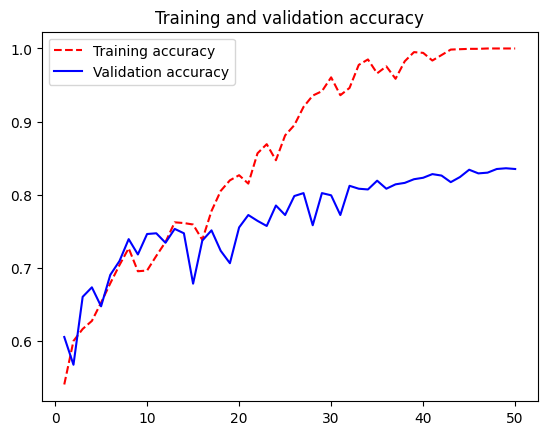

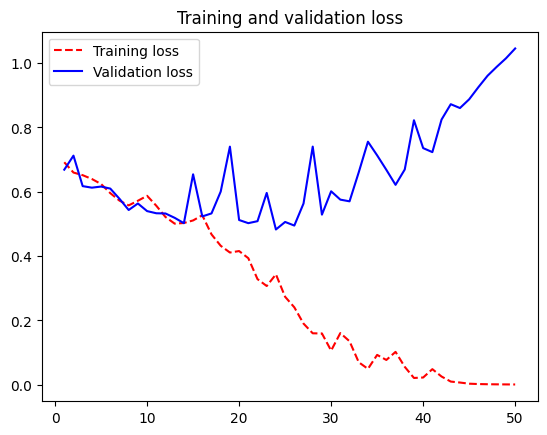

In [9]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

These plots are characteristic of overfitting. The training accuracy increases linearly over time, until it reaches nearly 100%, whereas the validation accuracy peaks around 80%. The validation loss reaches its minimum after only 10 epochs and then stalls, whereas the training loss keeps decreasing linearly as training proceeds.



In [10]:
test_model = keras.models.load_model("convnet_from_scratch.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.7955 - loss: 0.4947
Test accuracy: 0.795


### Data augmentation to reduce overfitting

In [23]:
# Defines the transformations to apply as a list
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
]

# Creates a function that applies them sequentially
def data_augmentation(images, targets):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images, targets

# Maps this function into the dataset
augmented_train_dataset = train_dataset.map(
    data_augmentation, num_parallel_calls=8
)

RandomFlip("horizontal") will apply horizontal flipping to a random 50% of the images that go through it.

RandomRotation(0.1) will rotate the input images by a random value in the range [–10%, +10%] (these are fractions of a full circle — in degrees the range would be [–36 degrees, +36 degrees]).

RandomZoom(0.2) will zoom in or out of the image by a random factor in the range [–20%, +20%].

2025-11-14 09:56:23.165164: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


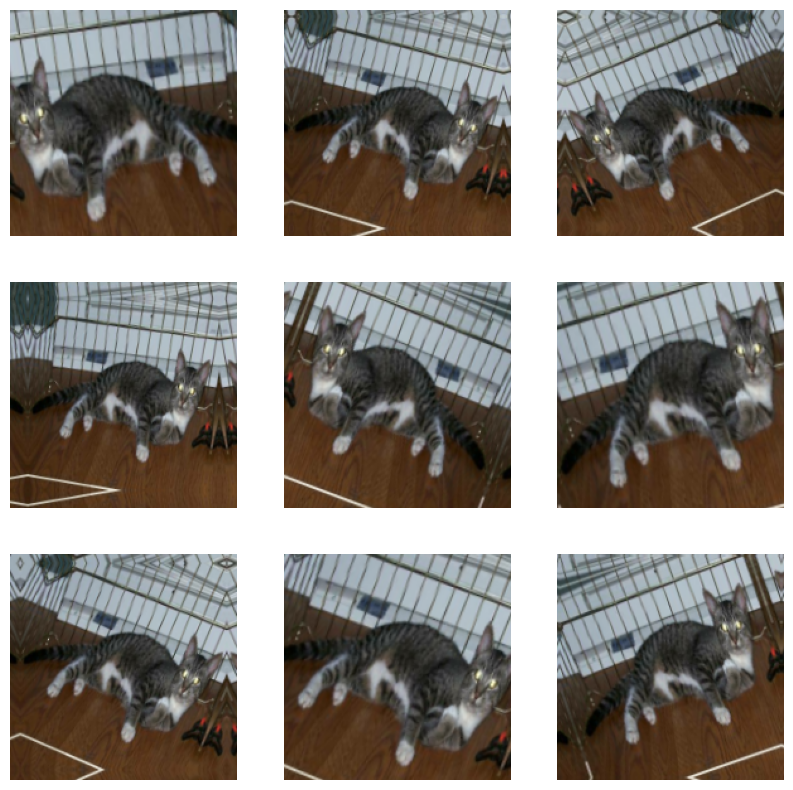

In [13]:
plt.figure(figsize=(10, 10))
# You can use take(N) to only sample N batches from the dataset. This
# is equivalent to inserting a break in the loop after the Nth batch.
for image_batch, _ in train_dataset.take(1):
    image = image_batch[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image, _ = data_augmentation(image, None)
        augmented_image = keras.ops.convert_to_numpy(augmented_image)
        # Displays the first image in the output batch. For each of the
        # nine iterations, this is a different augmentation of the same
        # image.
        plt.imshow(augmented_image.astype("uint8"))
        plt.axis("off")

If you train a new model using this data augmentation configuration, the model will never see the same input twice. But the inputs it sees are still heavily intercorrelated, because they come from a small number of original images — you can’t produce new information; you can only remix existing information. As such, this may not be enough to completely get rid of overfitting. To further fight overfitting, you’ll also add a Dropout layer to your model, right before the densely connected classifier.

In [14]:
inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1.0 / 255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [15]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    augmented_train_dataset,
    # Since we expect the model to overfit slower, we train for more
    # epochs.
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 377ms/step - accuracy: 0.4920 - loss: 0.7039 - val_accuracy: 0.5490 - val_loss: 0.6924
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 380ms/step - accuracy: 0.5075 - loss: 0.6928 - val_accuracy: 0.5550 - val_loss: 0.6899
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 377ms/step - accuracy: 0.5145 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 380ms/step - accuracy: 0.5190 - loss: 0.6909 - val_accuracy: 0.5150 - val_loss: 0.6907
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 386ms/step - accuracy: 0.5515 - loss: 0.6858 - val_accuracy: 0.5550 - val_loss: 0.6778
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 393ms/step - accuracy: 0.5995 - loss: 0.6679 - val_accuracy: 0.5270 - val_loss: 0.6839
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 386ms/step - accuracy: 0.6180 - loss: 0.6490 - val_accuracy: 0.5390 - val_loss: 0.6871
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 391ms/step - accuracy: 0.6395 - loss: 0.6409 - 

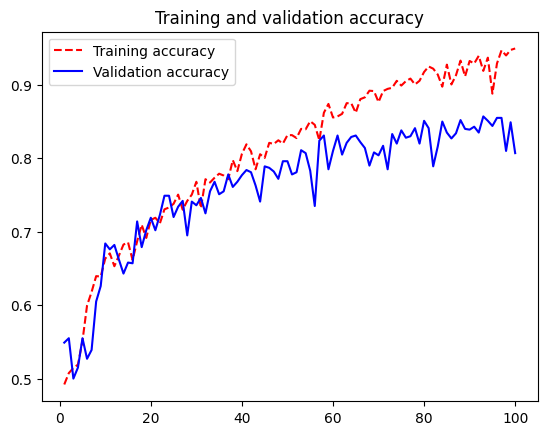

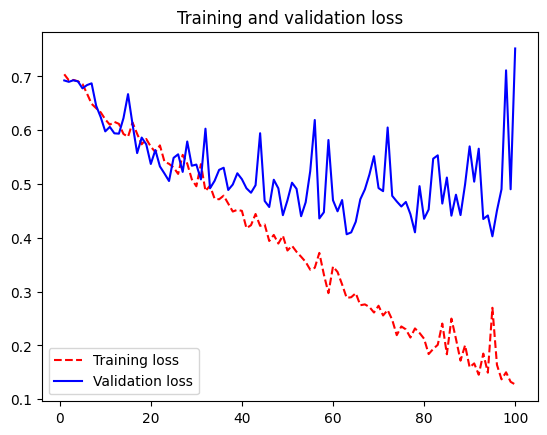

In [16]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [17]:
test_model = keras.models.load_model(
    "convnet_from_scratch_with_augmentation.keras"
)
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.8400 - loss: 0.4346 
Test accuracy: 0.840


# Using a pre-trained model (a.k.a TRANSFER LEARNING)

A pretrained model is a model that was previously trained on a large dataset, typically on a large-scale image-classification task.

<img src="./images/dl_cnn_14.png" width=1000 />

<img src="./images/dl_cnn_15.png" width=1000 />

<img src="./images/dl_cnn_16.png" width=1000 />

<img src="./images/dl_cnn_17.png" width=1000 />

For instance, you might train a model on ImageNet (where classes are mostly animals and everyday objects) and then repurpose this trained model for something as remote as identifying furniture items in images

In this case, let’s consider a large ConvNet trained on the ImageNet dataset (1.4 million labeled images and 1,000 different classes). ImageNet contains many animal classes, including different species of cats and dogs, and you can thus expect it to perform well on the dogs-versus-cats classification problem

### Feature extraction

Feature extraction consists of using the representations learned by a previously trained model to extract interesting features from new samples. These features are then run through a new classifier, which is trained from scratch.

<img src="./images/dl_cnn_8.png" width=1000 />

Representations learned by the convolutional base are likely to be more generic and therefore more reusable

But the representations learned by the classifier will necessarily be specific to the set of classes on which the model was trained.

Note that the level of generality (and therefore reusability) of the representations extracted by specific convolution layers depends on the depth of the layer in the model.

Layers that come earlier in the model extract local, highly generic feature maps (such as visual edges, colors, and textures), whereas layers that are higher up extract more abstract concepts (such as “cat ear” or “dog eye”)

In [2]:
import keras_hub

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
conv_base = keras_hub.models.Backbone.from_preset("xception_41_imagenet")

You load the Xception-41 CNN architecture.

It comes pretrained on ImageNet (1.2M images, 1000 classes).

It contains all convolutional layers, trained weights, etc.

This model is used as a feature extractor in transfer learning.

conv_base is a CNN that outputs feature maps, not final class scores.

In [4]:
preprocessor = keras_hub.layers.ImageConverter.from_preset(
    "xception_41_imagenet",
    image_size=(180, 180),
)

Every pretrained model expects images to be preprocessed in a specific way.

You must use the same preprocessing that the model was trained with on ImageNet.


ImageConverter automatically:

Resizes input images

Normalizes pixel values

Applies Xception’s preprocessing rules

Converts them into tensors ready for the backbone

Using the same preset ensures complete compatibility.


In [8]:
import numpy as np

def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = preprocessor(images)
        features = conv_base.predict(preprocessed_images, verbose=0)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

2025-11-16 11:36:10.741218: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-16 11:36:21.355783: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Implicit freezing of layers - You run the CNN once to generate features and then throw away the CNN during training.

Runs the convolutional base in inference mode

Does not compute gradients

Does not update weights

In [9]:
train_features.shape

(2000, 6, 6, 2048)

In [12]:
import keras
from keras import layers 

inputs = keras.Input(shape=(6, 6, 2048))
# Averages spatial dimensions to flatten the feature map
x = layers.GlobalAveragePooling2D()(inputs)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    train_features,
    train_labels,
    epochs=10,
    validation_data=(val_features, val_labels),
    callbacks=callbacks,
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9710 - loss: 0.0864 - val_accuracy: 0.9790 - val_loss: 0.0593
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9900 - loss: 0.0309 - val_accuracy: 0.9870 - val_loss: 0.0448
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9950 - loss: 0.0153 - val_accuracy: 0.9880 - val_loss: 0.0551
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9990 - loss: 0.0069 - val_accuracy: 0.9860 - val_loss: 0.0490
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9985 - loss: 0.0048 - val_accuracy: 0.9890 - val_loss: 0.0504
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9990 - loss: 0.0042 - val_accuracy: 0.9840 - val_loss: 0.0746
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9965 - loss: 0.0093 - val_accuracy: 0.9690 - val_loss: 0.1323
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9940 - loss: 0.0187 - val_accuracy: 0.9810 - val_loss:

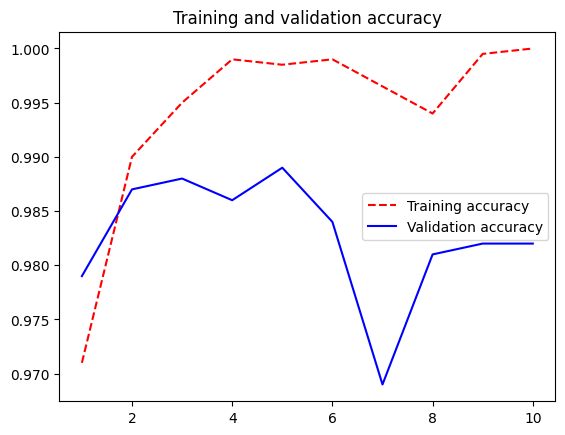

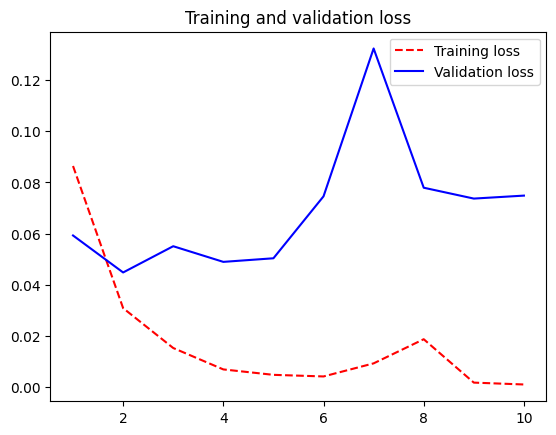

In [13]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [14]:
test_model = keras.models.load_model("feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_features, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - accuracy: 0.9840 - loss: 0.0539
Test accuracy: 0.984


### Explicit freezing of layers

In [15]:
import keras_hub

conv_base = keras_hub.models.Backbone.from_preset(
    "xception_41_imagenet",
    trainable=False,
)

Freezing a layer or set of layers means preventing their weights from being updated during training. 

Here, if you don’t do this, then the representations that were previously learned by the convolutional base will be modified during training.

In [16]:
conv_base.trainable = True
len(conv_base.trainable_weights)

154

In [17]:
conv_base.trainable = False
len(conv_base.trainable_weights)

0

In [43]:
inputs = keras.Input(shape=(180, 180, 3))
x = preprocessor(inputs)
x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [44]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_with_data_augmentation.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    
    # keras.callbacks.EarlyStopping(
    #     monitor="val_loss",       # what metric to watch
    #     patience=5,               # stop if no improvement for 5 epochs
    #     restore_best_weights=True  # Restores the weights from the epoch with the best validation score.
    # )
]

history = model.fit(
    augmented_train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 761ms/step - accuracy: 0.9295 - loss: 0.1854 - val_accuracy: 0.9770 - val_loss: 0.0894
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 764ms/step - accuracy: 0.9575 - loss: 0.1420 - val_accuracy: 0.9800 - val_loss: 0.0731
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 770ms/step - accuracy: 0.9630 - loss: 0.1106 - val_accuracy: 0.9870 - val_loss: 0.0544
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 769ms/step - accuracy: 0.9710 - loss: 0.0689 - val_accuracy: 0.9780 - val_loss: 0.0821
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 757ms/step - accuracy: 0.9715 - loss: 0.0803 - val_accuracy: 0.9860 - val_loss: 0.0449
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 770ms/step - accuracy: 0.9750 - loss: 0.0596 - val_accuracy: 0.9880 - val_loss: 0.0428
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 768ms/step - accuracy: 0.9805 - loss: 0.0551 - val_accuracy: 0.9820 - val_loss: 0.0558
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 758ms/step - accuracy: 0.9805 - loss: 0.0527 - val_accu

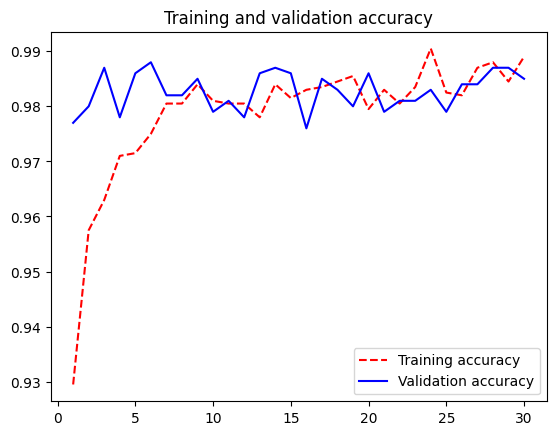

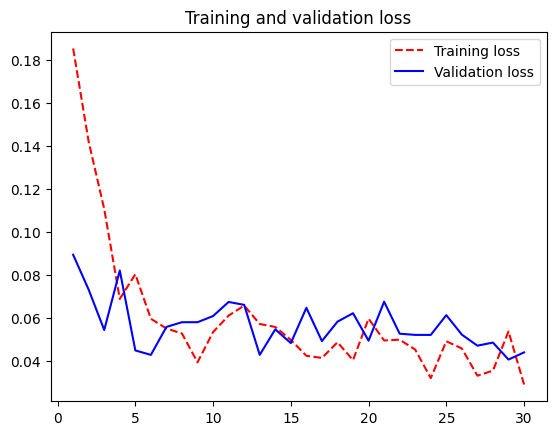

In [45]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

# Fine-tuning

It slightly adjusts the more abstract representations of the model being reused to make them more relevant for the problem at hand.

1.  Add your custom classifier on top of a pretrained CNN

2.  Freeze the pretrained CNN

3.  Train the new classifier only - Now only the top layers learn how to use the CNN’s features. This stabilizes training.

4.  Unfreeze (some or all) of the CNN

5.  Jointly train both CNN + classifier with a LOW learning rate - This adjusts the CNN slightly without destroying what it previously  learned.




Let's do partial fine-tuning — unfreezing ONLY the last few convolution layers of the pretrained model while keeping the rest frozen.

In [48]:
conv_base.trainable = True

# This loops through all layers except the last 4 layers and freezes them.

for layer in conv_base.layers[:-4]:
    layer.trainable = False

The first N-4 layers → FROZEN - (their weights will NOT update during training)

The last 4 layers → UNFROZEN - (their weights WILL update during training)

So you end up fine-tuning only the last 4 convolutional layers.

This is the best practice for fine-tuning:

The early layers of conv nets learn very general patterns
(edges, textures, simple shapes) → You don’t want to modify them.

The deeper layers learn more specialized patterns
(object parts, details) → You want to adapt these to your new dataset.

If you unfreeze too many layers → model forgets pretrained knowledge

In [49]:
inputs = keras.Input(shape=(180, 180, 3))
x = preprocessor(inputs)
x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    augmented_train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 837ms/step - accuracy: 0.7545 - loss: 0.5634 - val_accuracy: 0.9390 - val_loss: 0.3713
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 842ms/step - accuracy: 0.9225 - loss: 0.3534 - val_accuracy: 0.9660 - val_loss: 0.2364
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 858ms/step - accuracy: 0.9485 - loss: 0.2561 - val_accuracy: 0.9760 - val_loss: 0.1713
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 858ms/step - accuracy: 0.9625 - loss: 0.2041 - val_accuracy: 0.9770 - val_loss: 0.1352
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 856ms/step - accuracy: 0.9630 - loss: 0.1688 - val_accuracy: 0.9800 - val_loss: 0.1118
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 861ms/step - accuracy: 0.9585 - loss: 0.1498 - val_accuracy: 0.9800 - val_loss: 0.0966
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 860ms/step - accuracy: 0.9600 - loss: 0.1407 - val_accuracy: 0.9810 - val_loss: 0.0859
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 859ms/step - accuracy: 0.9660 - loss: 0.1225 - val_accu

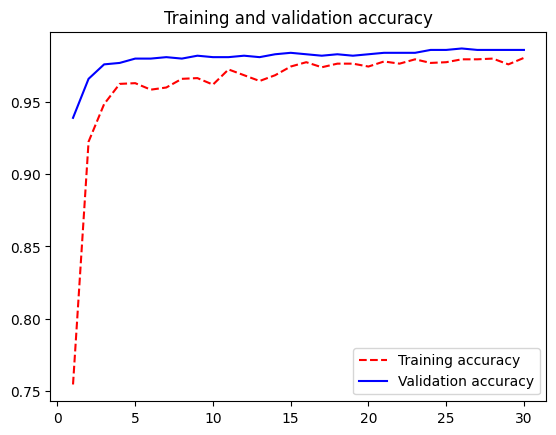

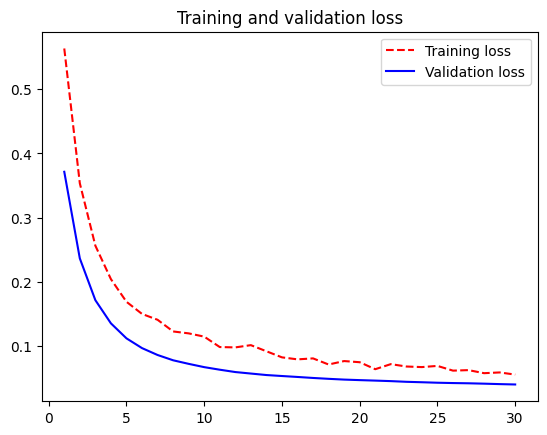

In [50]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()